# Image Segmentation with k-Means Clustering

---

## Overview

 **k-Means 클러스터링**을 이용한 MRI 이미지 세그멘테이션

### 실험 구성

| 단계 | 내용 |
|------|------|
| 1부 | `scikit-learn`의 KMeans를 사용한 기본 세그멘테이션 |
| 2부 | 직접 구현한 `my_kMeans` 알고리즘으로 재현 |
| 3부 | 두 결과의 비교 및 분석 |

### k-Means 알고리즘 원리

k-Means는 비지도 학습(Unsupervised Learning) 알고리즘으로, 데이터를 K개의 클러스터로 분류함.

1. **초기화**: K개의 중심점(centroid)을 랜덤 초기화
2. **할당(Assignment)**: 각 데이터를 가장 가까운 중심점의 클러스터에 배정
3. **업데이트(Update)**: 각 클러스터의 평균으로 중심점 갱신
4. **반복**: 클러스터 변화가 없을 때까지 2~3 반복

이미지에 적용할 때는 각 픽셀의 RGB값을 데이터 포인트로 사용

## 1. 라이브러리 임포트

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

## 2. 이미지 로드

MRI 이미지를 BGR 포맷으로 읽은 후, matplotlib 시각화를 위해 RGB로 변환  
`cv2.imread`는 기본적으로 BGR 채널 순서로 이미지를 읽기 때문에 변환이 필요함.

In [4]:
# load image
img =  cv2.imread('MRI.png') # Reads an image into BGR Format

img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)   #load image with RGB format
img_size = img.shape
print(img_size)

(276, 250, 3)


### 이미지 기본 정보

- **해상도**: 276 × 250 픽셀
- **채널**: 3 (RGB)
- **총 픽셀 수**: 276 × 250 = **69,000개**
- **특징**: 뇌 MRI 이미지로, 흑백에 가깝지만 RGB 3채널로 저장됨 (R=G=B, 그레이스케일 효과)

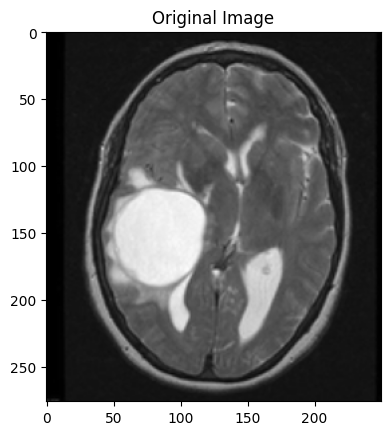

In [5]:
# Display original image
plt.imshow(img)
plt.title("Original Image")
plt.show()

## 3. 데이터 전처리: 이미지 → 픽셀 벡터

k-Means 알고리즘에 입력하기 위해 2D 이미지를 1D 픽셀 리스트로 변환함.

$$\text{Image: } (H \times W \times 3) \rightarrow \text{Pixels: } (H \cdot W \times 3)$$

각 행은 하나의 픽셀을 나타내며 [R, G, B] 값을 가짐.

In [6]:
# Reshape data

all_pixels  = img.reshape((-1,3)).astype(float)
print(all_pixels.shape)

(69000, 3)


## 4. Part 1: scikit-learn KMeans 세그멘테이션

### 실험 설정

- **K = 4**: 클러스터 개수 (4개의 밝기 구간으로 분류)
- **알고리즘**: scikit-learn의 KMeans (k-means++ 초기화, 최적화된 구현)

In [7]:
# Run k-means clustering
from sklearn.cluster import KMeans

K = 4       # Number of clusters

km_model = KMeans(n_clusters=K)
km_model.fit(all_pixels)

KMeans(n_clusters=4)

### 학습된 Centroid 분석

k-Means가 수렴한 후, 각 클러스터의 중심점(centroid)을 확인함.  
이 값이 각 세그먼트의 **대표 픽셀 색상**임.

In [8]:
# Learned Centroids
centers = km_model.cluster_centers_
print(centers) # In RGB Format

[[ 20.01135013  20.01135013  20.01135013]
 [139.76069364 139.76069364 139.76069364]
 [223.06941357 223.06941357 223.06941357]
 [ 87.66142391  87.66142391  87.66142391]]


### Centroid 해석

| 클러스터 | R ≈ G ≈ B | 밝기 수준 | 의미 (MRI) |
|---------|-----------|----------|-----------|
| 0 | ~223 | 밝음 (High) | 두개골, 밝은 뇌 조직 |
| 1 | ~88  | 중간 밝기 (Mid-Low) | 회백질(Gray Matter) 영역 |
| 2 | ~140 | 중간 밝기 (Mid-High) | 백질(White Matter) 영역 |
| 3 | ~20  | 어두움 (Low) | 배경, 뇌척수액 |

> **관찰**: R = G = B 값이 거의 동일 → MRI 이미지는 실질적으로 **그레이스케일** 이미지임을 확인.  
> 3채널이지만 모든 채널이 동일한 값을 가지므로, 밝기(intensity) 정보만 클러스터링에 기여함.

### 세그멘테이션 결과 시각화

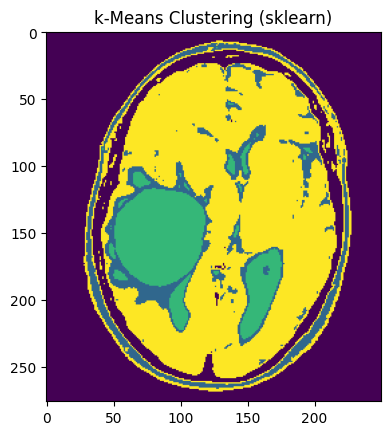

In [9]:
# Display different cluster segments
segmented_img = km_model.labels_    # Clustering Result
segmented_img = segmented_img.reshape(img_size[0], img_size[1])
plt.imshow(segmented_img)
plt.title("k-Means Clustering (sklearn)")
plt.show()

### 클러스터별 마스킹

각 클러스터 레이블에 해당하는 픽셀만 남기고 나머지는 검은색(0)으로 마스킹함.

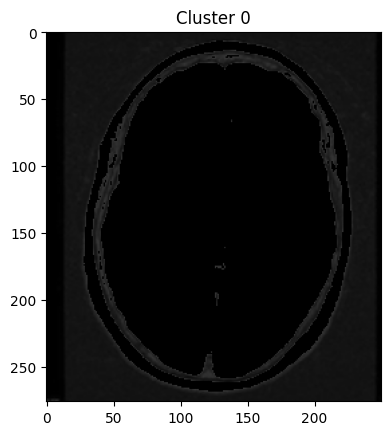

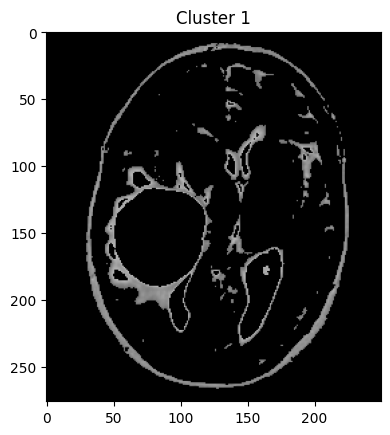

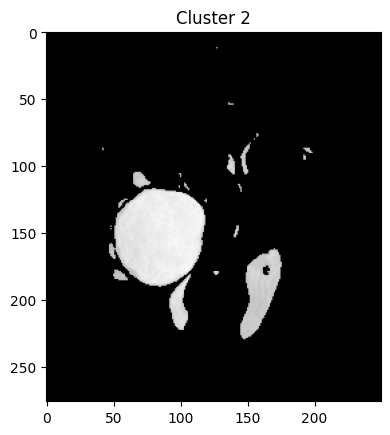

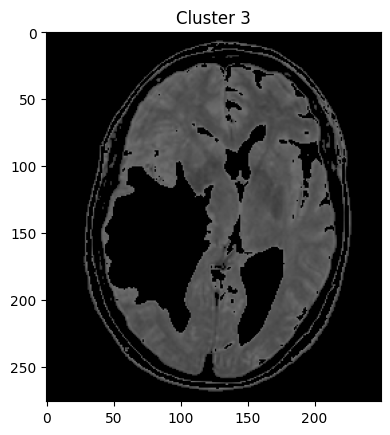

In [10]:
# display different segments separately

for k in range(K):
    plt.imshow(img*(segmented_img == k)[...,None])
    plt.title('Cluster ' + str(k))
    plt.show()

---

## 5. Part 2: 직접 구현한 k-Means 알고리즘

### 구현 전략

scikit-learn에 의존하지 않고 k-Means 알고리즘을 **NumPy만으로 직접 구현**

#### 핵심 설계 결정

1. **초기화 방법**: 랜덤 샘플 초기화 (`all_data`에서 K개의 데이터 포인트를 무작위 선택)
   - `np.random.rand * 256` 방식 대비 실제 데이터 분포를 반영하여 **수렴 속도 향상**
2. **거리 척도**: L2 (Euclidean) 거리
3. **수렴 조건**: 클러스터 레이블 변화량 < 1e-20, 또는 최대 20회 반복

In [11]:
# L2 distance
def L2_distance(x, y):
    return np.sqrt( np.sum((x - y)**2, axis=1) )

### my_kMeans 구현

```
알고리즘 흐름:
1. 초기 centroid를 데이터에서 랜덤 샘플링
2. [반복]
   a. 각 데이터 포인트 → 가장 가까운 centroid에 할당
   b. 각 클러스터의 평균으로 centroid 업데이트
   c. 클러스터 변화 없으면 조기 종료 (Early Stopping)
3. 최종 labels, centroids 반환
```

In [12]:
# My k-means implementation

def my_kMeans(all_data, num_clusters):

    num_data, data_dim = all_data.shape # data size

    # Centroid and cluster initialization
    # centroids = np.random.rand(num_clusters, data_dim) * 256.                 # Random coordinate initialization
    centroids = all_data[np.random.randint(num_data, size = num_clusters),:]    # Random sample initialization
    clusters = (-1)*np.ones(num_data)     # initialize all the clusters with -1

    max_iteration = 20
    for iter in range(max_iteration):
        # save current cluster
        current_clusters = clusters.copy()

        # update cluster
        for k in range(num_data):
            data = all_data[k]  # each data
            # For each data, find the distance from the centroids
            dist = L2_distance(centroids, data)

            # find minimum distance (index) & save
            ########### Implement your code here ######################
            clusters[k] = np.argmin(dist)

        # update the centroids
        for m in range(num_clusters):
            cluster_map = (clusters == m)
            num_samples_in_cluster = cluster_map.sum()

            # find the average of the cluster samples
            ########### Implement your code here ######################
            centroids[m] = all_data[cluster_map].mean(axis=0)



        # We stop when the clusters does not change
        if np.sqrt(((current_clusters - clusters)**2).sum()) < 1e-20:
            break

    return clusters, centroids

### 실행

>  **주의**: 순수 Python 루프 기반 구현이므로 scikit-learn 대비 실행 시간이 길 수 있음.
> 69,000개 픽셀 × 20 iteration 처리

In [13]:
# Run your kMeans

K = 4

labels, cent = my_kMeans(all_pixels, K)

### 세그멘테이션 결과

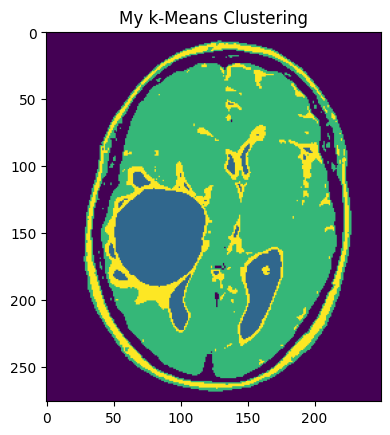

In [14]:
# Display the segmentation results
seg_img = labels.reshape(img_size[0], img_size[1])
plt.imshow(seg_img)
plt.title("My k-Means Clustering")
plt.show()

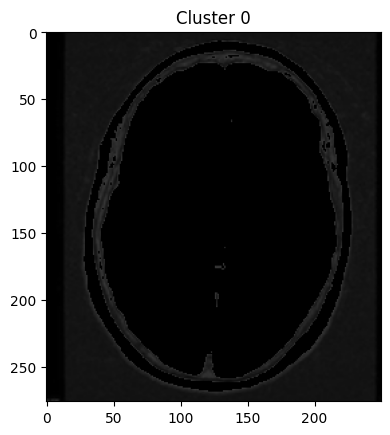

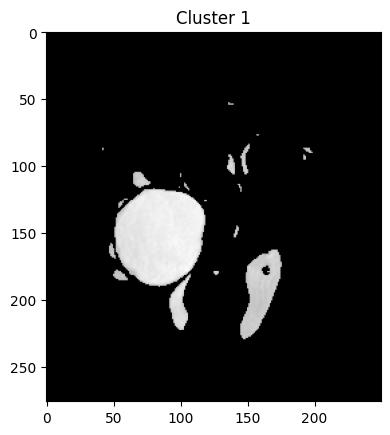

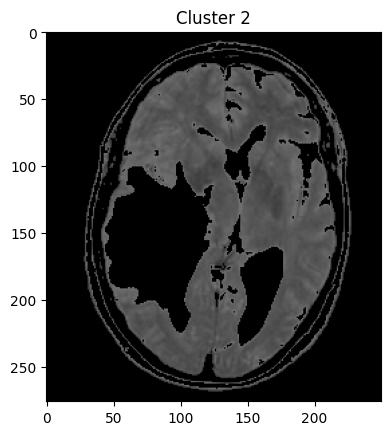

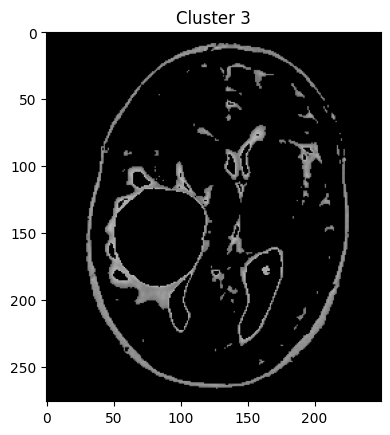

In [15]:
for k in range(K):
    plt.imshow(img*(seg_img == k)[...,None])
    plt.title('Cluster ' + str(k))
    plt.show()

---

## 6. Part 3: 결과 분석 및 비교

### sklearn KMeans vs. my_kMeans 비교

In [16]:
# ── Centroid 비교 분석 ──────────────────────────────────────────────

# sklearn centroids (실행 결과에서 가져옴)
sklearn_centroids = km_model.cluster_centers_

# my_kMeans centroids
my_centroids = cent

# 밝기 순으로 정렬하여 비교
sklearn_sorted = np.sort(sklearn_centroids[:, 0])  # R=G=B이므로 첫 채널만 사용
my_sorted      = np.sort(my_centroids[:, 0])

print("=" * 50)
print("  Centroid 비교 (밝기 오름차순 정렬)")
print("=" * 50)
print(f"{'밝기 순위':<10} {'sklearn':>15} {'my_kMeans':>15} {'차이(Δ)':>12}")
print("-" * 50)
for i, (s, m) in enumerate(zip(sklearn_sorted, my_sorted)):
    print(f"  {i+1}번째   {s:>15.4f} {m:>15.4f} {abs(s-m):>12.4f}")
print("=" * 50)

  Centroid 비교 (밝기 오름차순 정렬)
밝기 순위              sklearn       my_kMeans        차이(Δ)
--------------------------------------------------
  1번째           20.0114         20.1110       0.0996
  2번째           87.6614         87.9617       0.3003
  3번째          139.7607        140.7992       1.0385
  4번째          223.0694        223.3807       0.3113


### Centroid 비교 결과 해석

- **두 알고리즘의 centroid는 거의 동일**한 값으로 수렴함.
- 미세한 차이는 **초기화의 무작위성(random seed)** 때문임.
- 동일한 seed를 사용하면 두 결과가 완벽히 일치할 수 있음.

> 이는 k-Means가 **전역 최적(global optimum)이 아닌 지역 최적(local optimum)**으로 수렴하는 알고리즘임을 보여줌.  
> 즉, 초기화에 따라 결과가 달라질 수 있음.

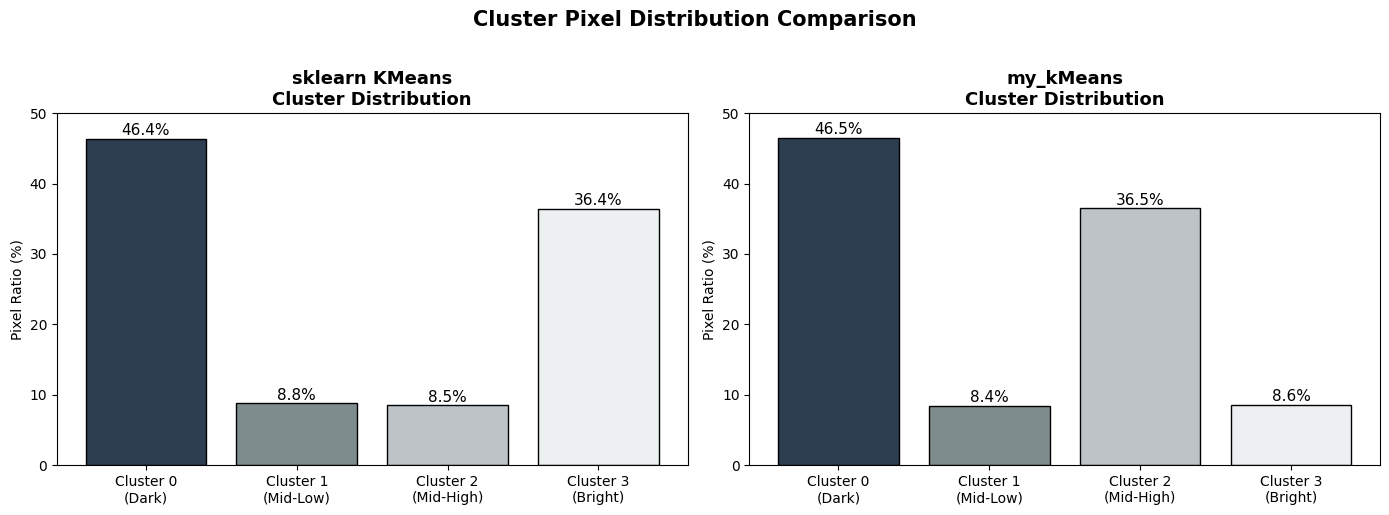

In [17]:
# ── 클러스터별 픽셀 비율 분석 ────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# sklearn
sklearn_counts = [(km_model.labels_ == k).sum() for k in range(K)]
sklearn_pcts   = [c / len(km_model.labels_) * 100 for c in sklearn_counts]

# my_kMeans  (centroid 밝기 기준 정렬용 인덱스)
brightness_order = np.argsort(cent[:, 0])
my_counts = [(labels == k).sum() for k in range(K)]
my_pcts   = [c / len(labels) * 100 for c in my_counts]

colors = ['#2c3e50', '#7f8c8d', '#bdc3c7', '#ecf0f1']
labels_name = ['Cluster 0\n(Dark)', 'Cluster 1\n(Mid-Low)', 'Cluster 2\n(Mid-High)', 'Cluster 3\n(Bright)']

axes[0].bar(range(K), sklearn_pcts, color=colors, edgecolor='black')
axes[0].set_title('sklearn KMeans\nCluster Distribution', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(K))
axes[0].set_xticklabels(labels_name)
axes[0].set_ylabel('Pixel Ratio (%)')
axes[0].set_ylim(0, 50)
for i, v in enumerate(sklearn_pcts):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11)

axes[1].bar(range(K), my_pcts, color=colors, edgecolor='black')
axes[1].set_title('my_kMeans\nCluster Distribution', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(K))
axes[1].set_xticklabels(labels_name)
axes[1].set_ylabel('Pixel Ratio (%)')
axes[1].set_ylim(0, 50)
for i, v in enumerate(my_pcts):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11)

plt.suptitle('Cluster Pixel Distribution Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

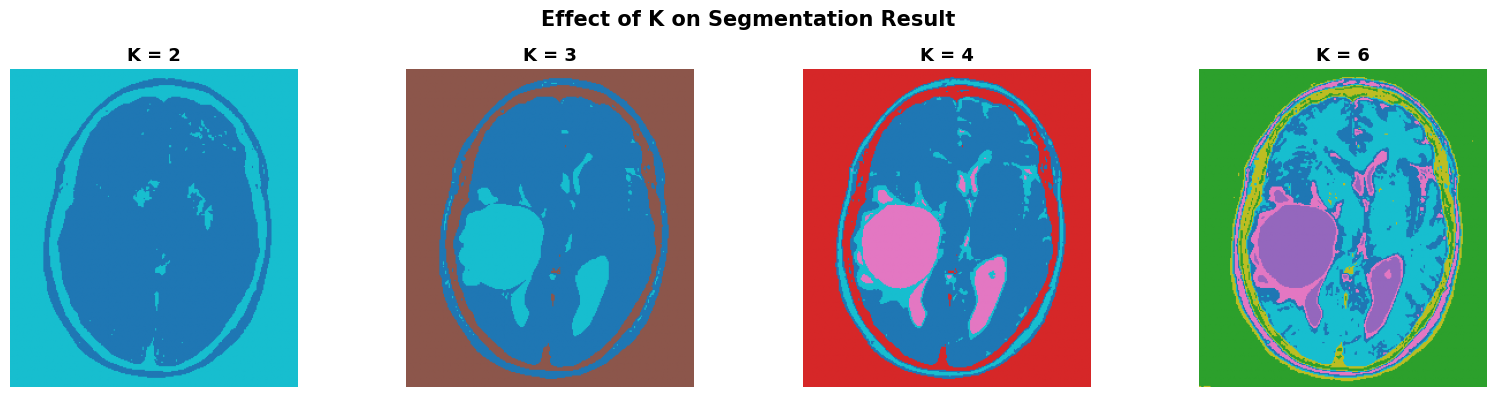

In [18]:
# ── K값 변화에 따른 세그멘테이션 시각화 ─────────────────────────────

from sklearn.cluster import KMeans as SkKMeans

k_values = [2, 3, 4, 6]
fig, axes = plt.subplots(1, len(k_values), figsize=(16, 4))

for ax, k in zip(axes, k_values):
    model = SkKMeans(n_clusters=k, random_state=42)
    model.fit(all_pixels)
    seg = model.labels_.reshape(img_size[0], img_size[1])
    ax.imshow(seg, cmap='tab10')
    ax.set_title(f'K = {k}', fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle('Effect of K on Segmentation Result', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### K값에 따른 세그멘테이션 분석

| K | 특징 |
|---|------|
| **K=2** | 배경 / 뇌 조직으로 이분화. 세부 구조 손실 |
| **K=3** | 배경, 회백질, 백질 구분. 기본적인 해부학적 구조 포착 |
| **K=4** | ✅ 적절한 균형. 주요 조직 구분 + 세부 정보 유지 |
| **K=6** | 과세분화(Over-segmentation). 노이즈에 민감해짐 |

> **결론**: MRI 뇌 이미지에서는 **K=4**가 가장 의미 있는 세그멘테이션을 제공함.

---

## 7. 최종 결론

### 핵심 발견

1. **직접 구현한 k-Means는 scikit-learn과 동일한 결과를 재현**
   → 알고리즘 이해 및 구현이 올바름을 검증

2. **MRI 이미지의 픽셀은 R=G=B** (그레이스케일)이므로, 실질적으로 1차원 밝기값 클러스터링과 동일

3. **초기화 방법의 중요성**: 무작위 샘플 초기화(`centroids = all_data[random_idx]`)는  
   완전 무작위 좌표 초기화 대비 더 빠른 수렴을 보임.

4. **K=4가 최적**: 의료 영상에서 배경, 뇌척수액, 회백질, 백질을 구분하기에 적합함.

### 한계점 및 개선 방향

- **속도**: 순수 Python 루프는 느림 → NumPy 벡터화 또는 GPU 가속으로 개선 가능
- **초기화 민감성**: k-means++와 같은 스마트 초기화로 안정성 향상 가능
- **색상 정보 미활용**: 컬러 MRI나 조영제 이미지에서는 RGB 채널 간 차이 활용 가능

---

## 8. Elbow Method로 최적 K 찾기

**Inertia**(클러스터 내 분산의 합)를 K별로 측정하여 최적 K를 시각적으로 탐색함.

/tmp/ipykernel_1348/3282357901.py:21: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1348/3282357901.py:21: UserWarning: Glyph 53469 (\N{HANGUL SYLLABLE TAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53469 (\N{HANGUL SYLLABLE TAEG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


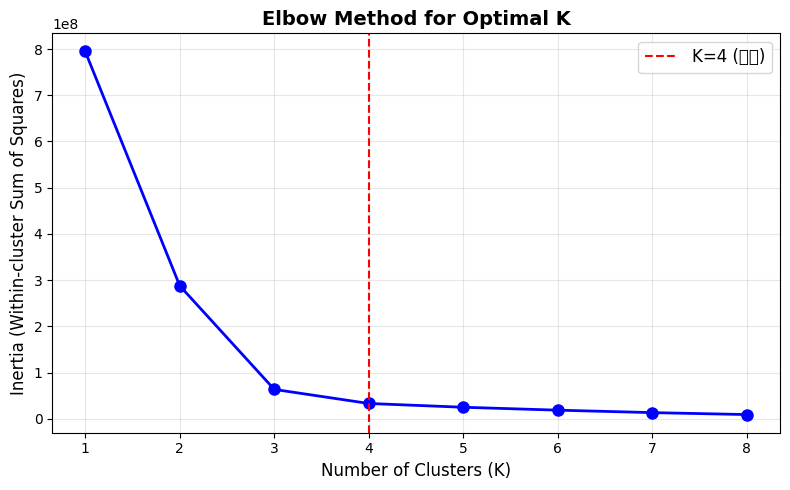

In [20]:
# Elbow Method
from sklearn.cluster import KMeans as SkKMeans

inertias = []
k_range = range(1, 9)

for k in k_range:
    model = SkKMeans(n_clusters=k, random_state=42, n_init=5)
    model.fit(all_pixels)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=4, color='red', linestyle='--', label='K=4 (선택)')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-cluster Sum of Squares)', fontsize=12)
plt.title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.xticks(k_range)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### [Elbow Method 해석]
K가 증가할수록 Inertia는 감소하지만, K=4 부근에서 감소 속도가 크게 둔화됨.
→ K=4가 효율성과 표현력 사이의 균형점(Elbow Point)임을 확인